In [79]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("data.csv")

def label(row):
    if row["hard_stop"] == 1:
        return "hard_stop"
    elif row["momentary_stop"] == 1:
        return "momentary_stop"
    else:
        return "none"



df["class"] = df.apply(label, axis=1)

In [68]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 584 entries, 0 to 583
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   total_stop_frames       584 non-null    int64  
 1   longest_stop_frames     584 non-null    int64  
 2   num_stop_events         584 non-null    int64  
 3   mean_stop_duration      584 non-null    float64
 4   mean_velocity           584 non-null    float64
 5   max_velocity            584 non-null    float64
 6   velocity_std            584 non-null    float64
 7   max_acceleration        584 non-null    float64
 8   max_deceleration        584 non-null    float64
 9   acceleration_std        584 non-null    float64
 10  position_std            584 non-null    float64
 11  frames_after_last_stop  584 non-null    int64  
 12  object_file             584 non-null    str    
 13  hard_stop               584 non-null    int64  
 14  momentary_stop          584 non-null    int64  
 15  

,total_stop_frames,longest_stop_frames,num_stop_events,mean_stop_duration,mean_velocity,max_velocity,velocity_std,max_acceleration,max_deceleration,acceleration_std,position_std,frames_after_last_stop,hard_stop,momentary_stop
count,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000,584.000000
mean,632.426370,611.753425,4.347603,605.364659,16.687469,30.683034,5.652599,14.763041,-4.318743,1.111890,622.646294,298.325342,0.066781,0.378425
std,2248.161245,2252.039771,7.660063,2253.437483,10.561142,12.803760,2.975686,9.775175,4.540874,0.930048,396.007119,223.011527,0.249856,0.485410
min,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-32.165000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,1.000000,6.620456,22.703000,3.742152,9.103750,-5.238750,0.533359,298.611703,123.000000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,1.000000,17.196485,31.105000,5.436542,13.213500,-2.947500,0.869978,551.231351,276.500000,0.000000,0.000000
75%,40.250000,16.000000,3.000000,5.517857,25.297575,39.476500,7.396227,19.759250,-1.842750,1.453020,1040.802535,431.500000,0.000000,1.000000
max,9022.000000,9022.000000,68.000000,9022.000000,48.487771,79.183000,15.770169,53.495000,0.000000,5.575316,1519.414577,1953.000000,1.000000,1.000000


In [69]:
X = df.drop(["object_file","hard_stop","momentary_stop","class"], axis=1)
y = df["class"]

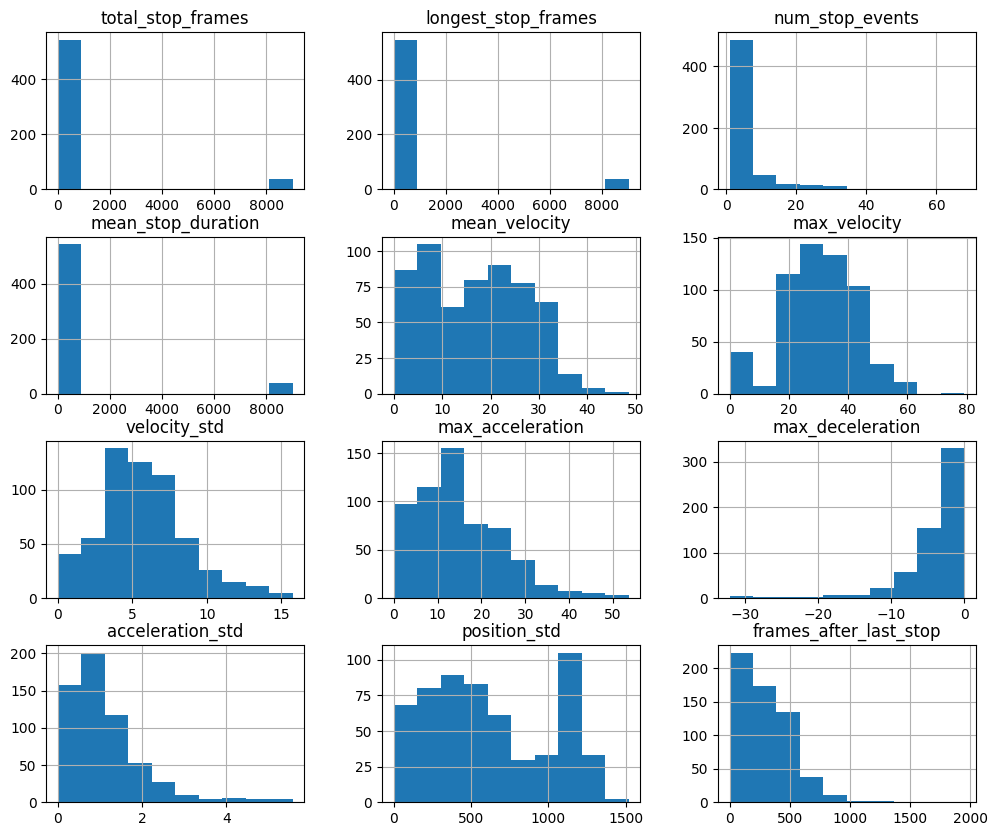

In [70]:
X.hist(figsize=(12,10))
plt.show()

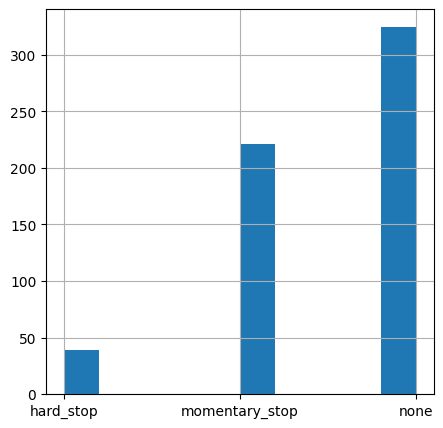

In [71]:
y.hist(figsize=(5,5))
plt.show()

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [73]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)
scores = cross_val_score(model, X, y, cv=skf)

print(scores)
print(scores.mean())

[1. 1. 1. 1. 1.]
1.0


In [74]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

     hard_stop       1.00      1.00      1.00         8
momentary_stop       1.00      1.00      1.00        44
          none       1.00      1.00      1.00        65

      accuracy                           1.00       117
     macro avg       1.00      1.00      1.00       117
  weighted avg       1.00      1.00      1.00       117



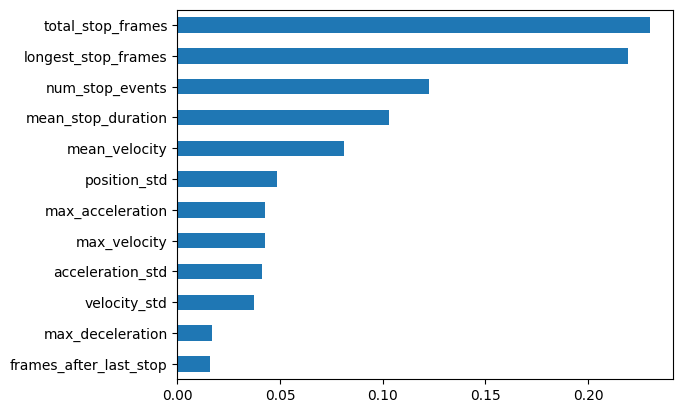

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.show()

In [86]:
correlation_matrix = X.corr()
correlation_matrix = round(correlation_matrix, 2)

print(correlation_matrix)


                        total_stop_frames  longest_stop_frames  \
total_stop_frames                    1.00                 1.00   
longest_stop_frames                  1.00                 1.00   
num_stop_events                     -0.08                -0.11   
mean_stop_duration                   1.00                 1.00   
mean_velocity                       -0.44                -0.43   
max_velocity                        -0.64                -0.64   
velocity_std                        -0.50                -0.51   
max_acceleration                    -0.41                -0.40   
max_deceleration                     0.26                 0.25   
acceleration_std                    -0.33                -0.32   
position_std                        -0.43                -0.42   
frames_after_last_stop              -0.36                -0.36   

                        num_stop_events  mean_stop_duration  mean_velocity  \
total_stop_frames                 -0.08                1.00    

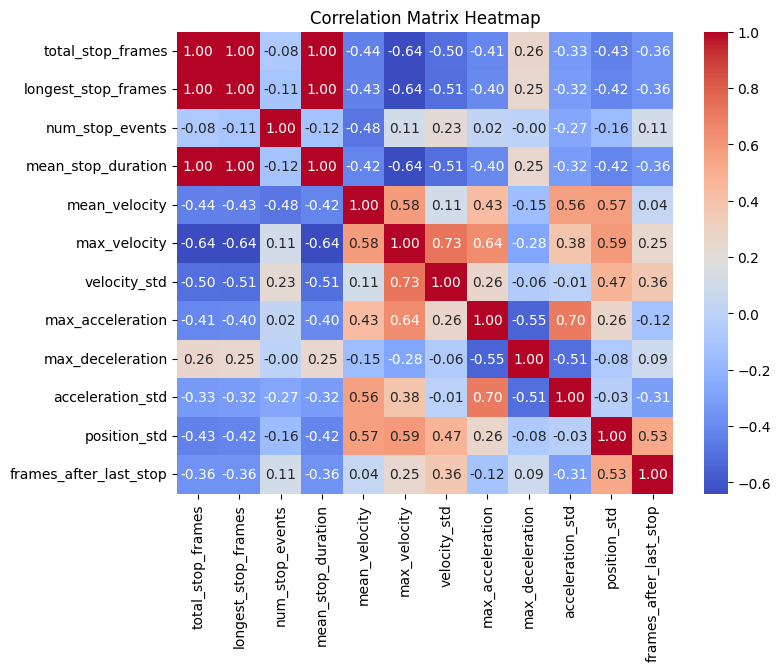

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt # Used for displaying the plot

# Assuming 'correlation_matrix' from the previous step
plt.figure(figsize=(8, 6)) # Adjust the figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()